## STEP-3 EDA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("data/cleaned_data.csv")

REG_TARGET = 'max_monthly_emi'
CLASS_TARGET = 'emi_eligibility'

print(f"Dataset loaded: {df.shape}")

Dataset loaded: (404795, 27)


In [2]:
print(df.columns.tolist())
df.head()

['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'emi_eligibility', 'max_monthly_emi']


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,female,married,professional,82600.0,private,0.9,mid_size,rented,20000.0,...,yes,20000.0,660.0,303200.0,70200.0,personal_loan_emi,850000.0,15,not_eligible,500.0
1,38,female,married,graduate,21500.0,private,7.0,mnc,family,0.0,...,yes,4100.0,714.0,92500.0,26900.0,e_commerce_shopping_emi,128000.0,19,not_eligible,700.0
2,38,male,married,professional,86100.0,private,5.8,startup,own,0.0,...,no,0.0,650.0,665050.0,268900.0,education_emi,306000.0,16,eligible,27775.0
3,58,female,married,high_school,66800.0,private,2.2,mid_size,own,0.0,...,no,0.0,685.0,440900.0,178100.0,vehicle_emi,304000.0,83,eligible,16170.0
4,48,female,married,professional,57300.0,private,3.4,mid_size,family,0.0,...,no,0.0,770.0,97300.0,28200.0,home_appliances_emi,252000.0,7,not_eligible,500.0


In [3]:
#TRAIN TEST SPLIT
X = df.drop(columns=[REG_TARGET, CLASS_TARGET])
y_reg = df[REG_TARGET]
y_clf = df[CLASS_TARGET]

X_train, X_temp, y_train_reg, y_temp_reg, y_train_clf, y_temp_clf = train_test_split(
    X, y_reg, y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf
)

X_val, X_test, y_val_reg, y_test_reg, y_val_clf, y_test_clf = train_test_split(
    X_temp, y_temp_reg, y_temp_clf,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_clf
)

print(X_train.shape, X_val.shape, X_test.shape)

(283356, 25) (60719, 25) (60720, 25)


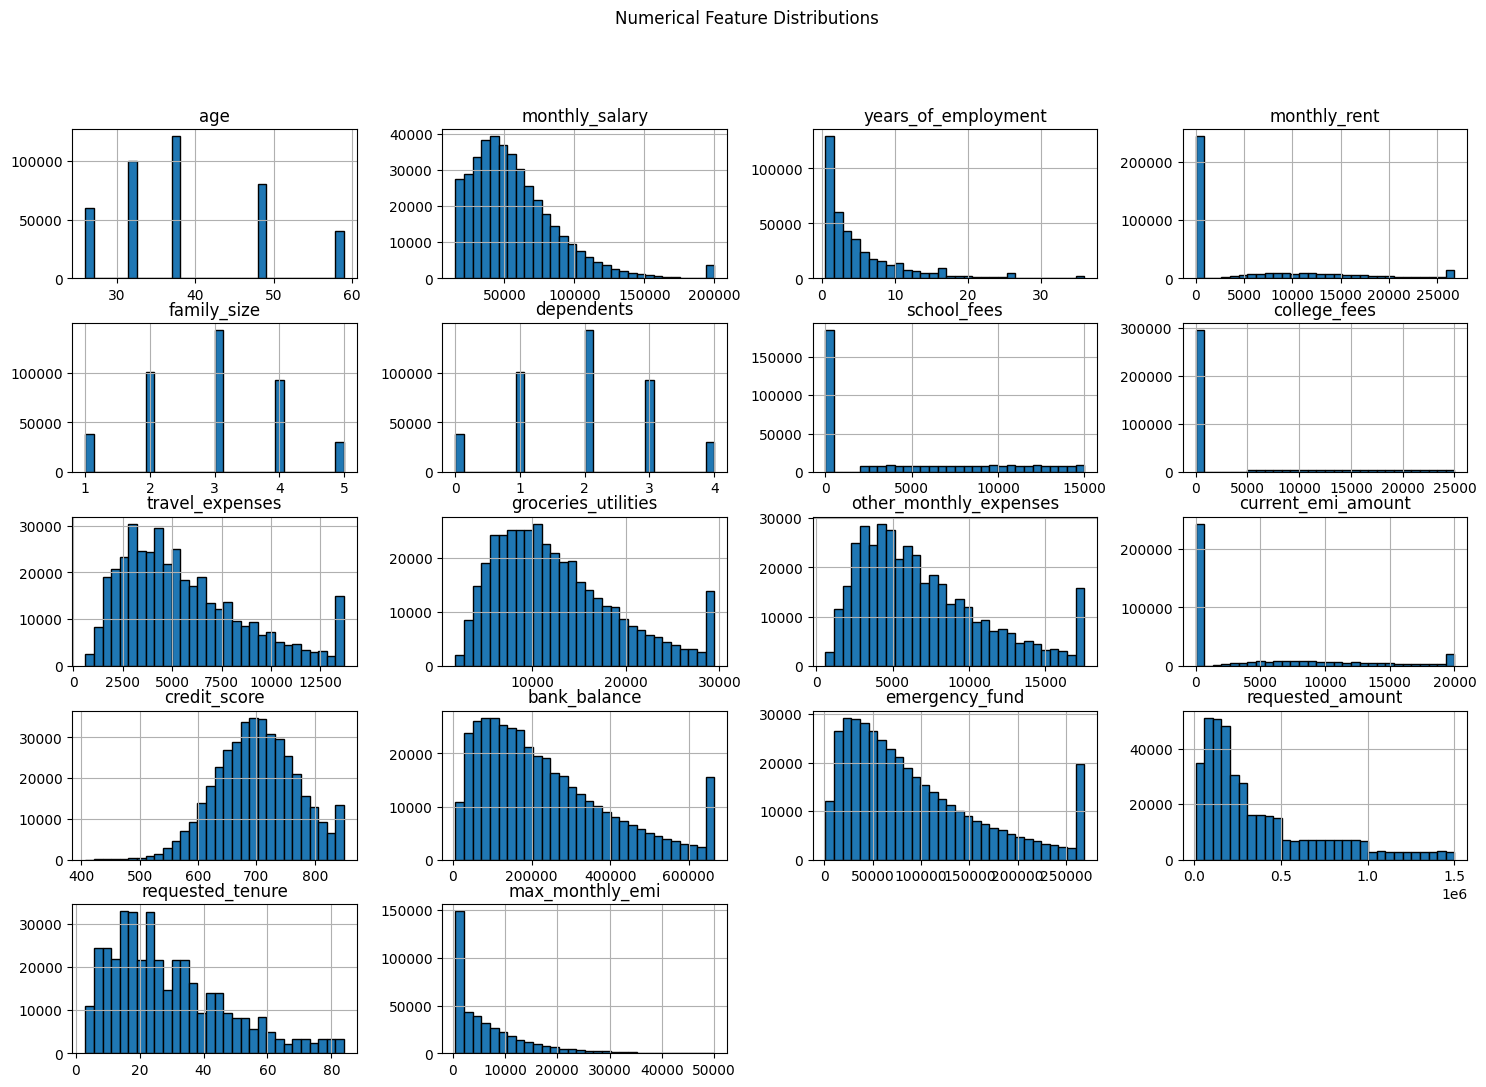

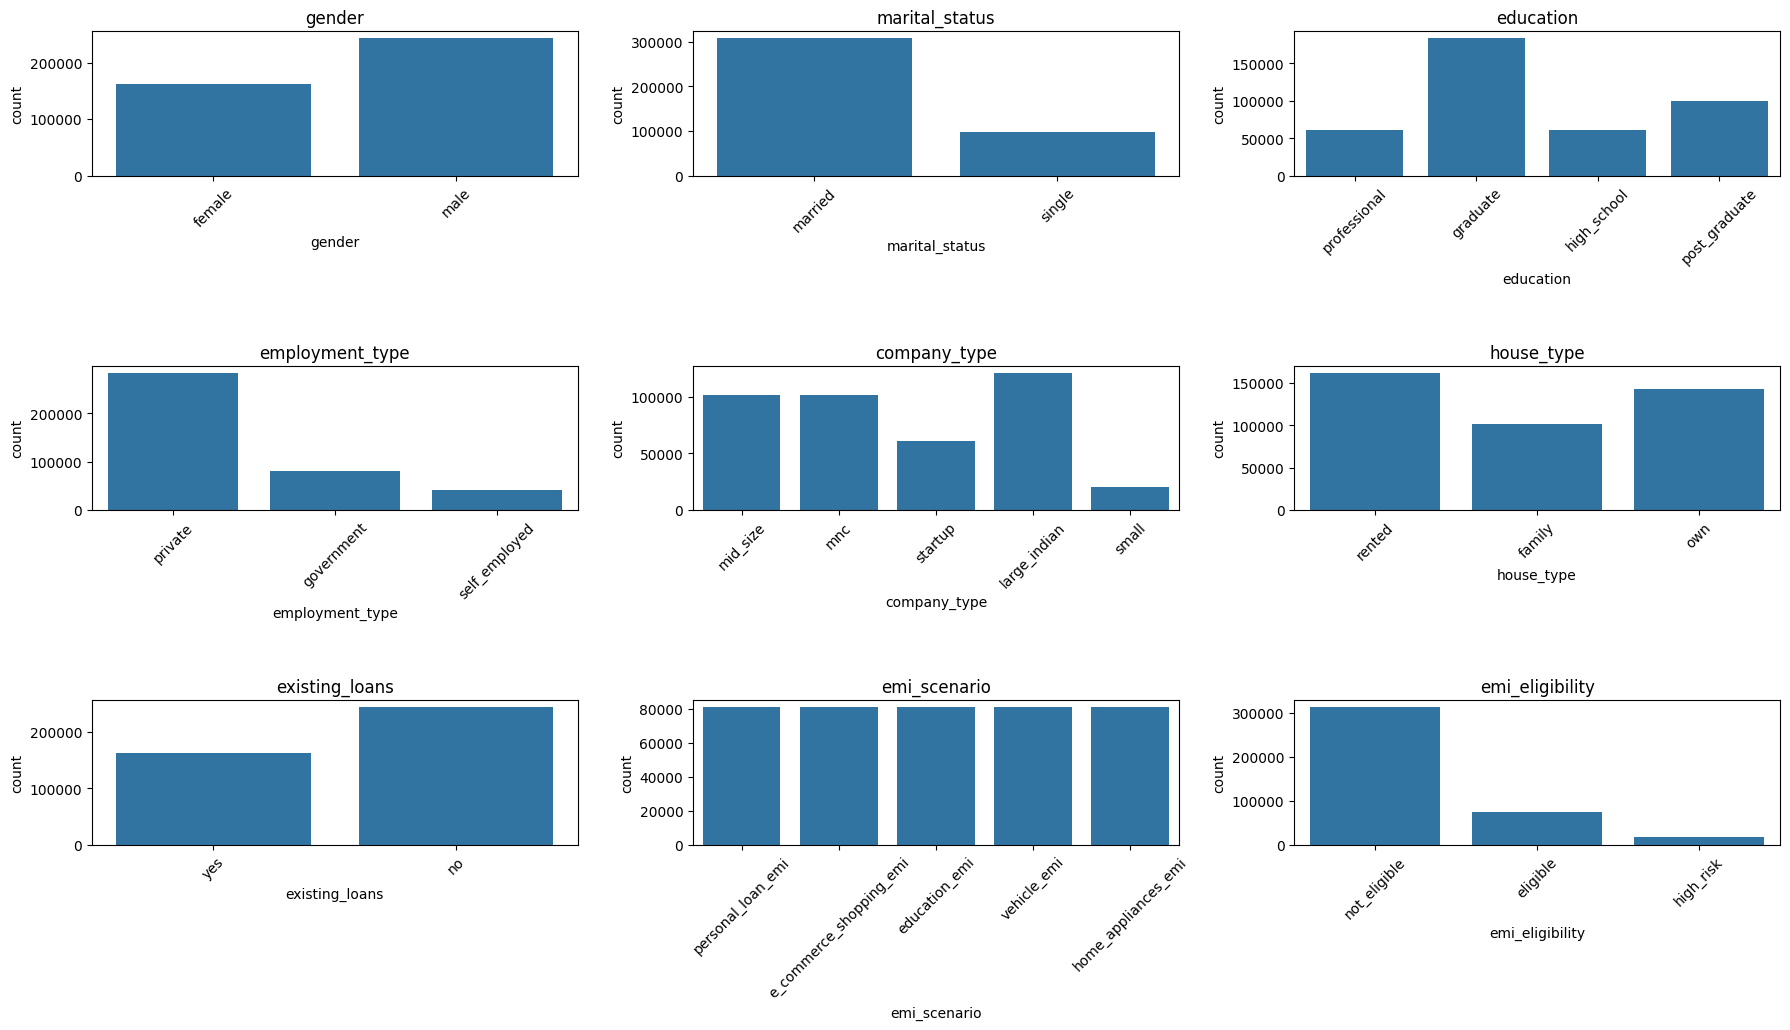

In [4]:
# Numerical distribution
df.select_dtypes(include=['int64','float64']).hist(
    bins=30, figsize=(18, 12), edgecolor='black'
)
plt.suptitle("Numerical Feature Distributions")
plt.show()

# Categorical distribution
plt.figure(figsize=(18, 12))
categorical_cols = df.select_dtypes(include=['object']).columns

for i, col in enumerate(categorical_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

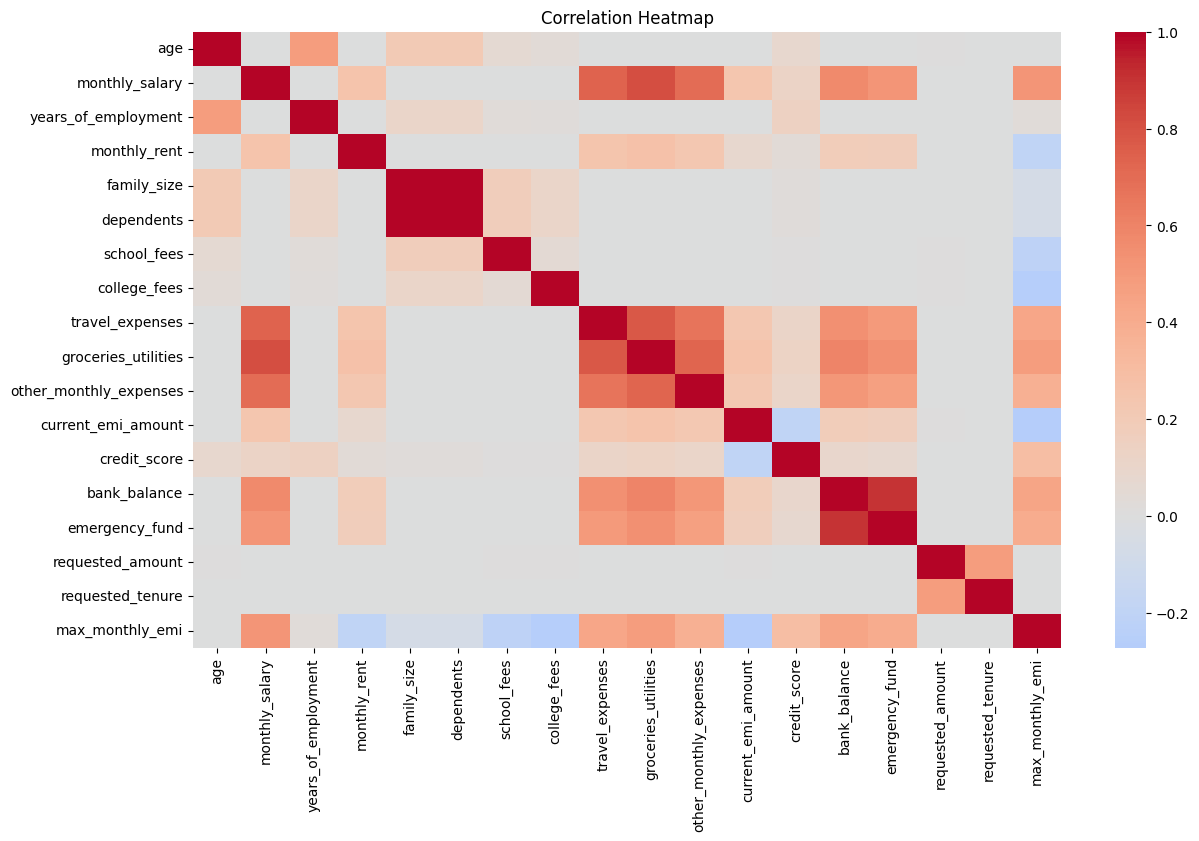

In [28]:
plt.figure(figsize=(14, 8))
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

count    283356.000000
mean       6757.924605
std        7689.384851
min         500.000000
25%         500.000000
50%        4211.000000
75%        9800.000000
max       50000.000000
Name: max_monthly_emi, dtype: float64


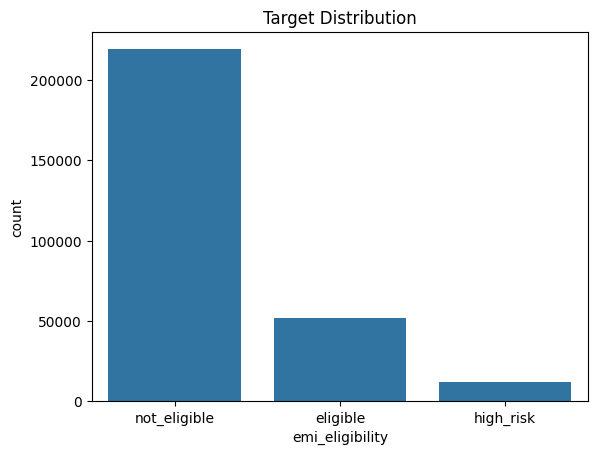

In [29]:
print(y_train_reg.describe())

sns.countplot(x=y_train_clf)
plt.title("Target Distribution")
plt.show()

C:\Users\nlalr\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


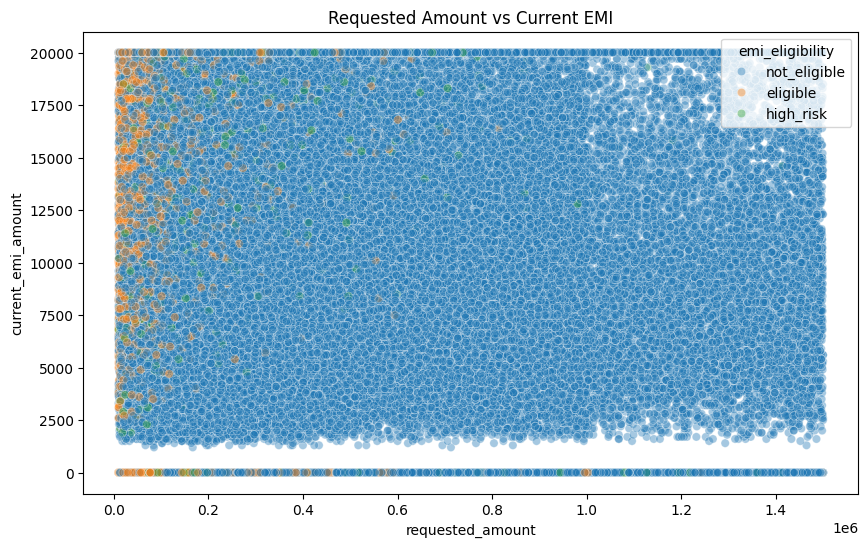

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='requested_amount',
    y='current_emi_amount',
    hue='emi_eligibility',
    alpha=0.4
)

plt.title("Requested Amount vs Current EMI")
plt.show()

In [5]:
# Create train_analysis (no leakage)
train_analysis = X_train.copy()
train_analysis['emi_eligibility'] = y_train_clf.values

# Approval rate by scenario
scenario_eligibility = pd.crosstab(
    train_analysis['emi_scenario'],
    train_analysis['emi_eligibility'],
    normalize='index'
) * 100

print(scenario_eligibility.round(2))

emi_eligibility          eligible  high_risk  not_eligible
emi_scenario                                              
e_commerce_shopping_emi     26.33       4.93         68.75
education_emi               17.68       4.81         77.50
home_appliances_emi         26.03       5.21         68.76
personal_loan_emi           11.37       3.40         85.22
vehicle_emi                 10.57       3.25         86.18


In [6]:
train_analysis['total_expenses'] = train_analysis[
    ['monthly_rent','school_fees','college_fees','travel_expenses',
     'groceries_utilities','other_monthly_expenses']
].sum(axis=1)

train_analysis['dti_ratio'] = train_analysis['current_emi_amount'] / train_analysis['monthly_salary']

train_analysis['expense_ratio'] = train_analysis['total_expenses'] / train_analysis['monthly_salary']

train_analysis['total_burden_ratio'] = (
    train_analysis['current_emi_amount'] + train_analysis['total_expenses']
) / train_analysis['monthly_salary']

print(train_analysis.groupby('emi_eligibility')['dti_ratio'].mean())

emi_eligibility
eligible        0.027560
high_risk       0.038971
not_eligible    0.093250
Name: dti_ratio, dtype: float64


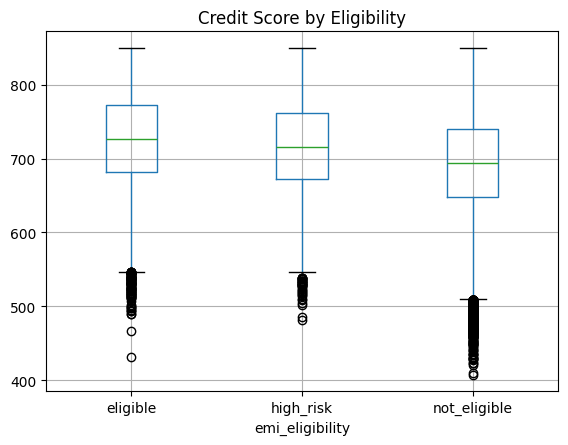

In [7]:
train_analysis.boxplot(column='credit_score', by='emi_eligibility')
plt.title("Credit Score by Eligibility")
plt.suptitle("")
plt.show()

### Key Insights:

1. High DTI ratio strongly correlates with rejection
2. Credit score < 700 significantly reduces approval chances
3. Income plays a major role in eligibility
4. Existing EMI burden increases rejection probability
5. Certain EMI scenarios (like vehicle loans) have lower approval rates

In [8]:
def engineer_features(df):
    df_new = df.copy()
    
    # -----------------------------
    # Drop unnecessary columns
    # -----------------------------
    df_new = df_new.drop(columns=['dependents', 'emergency_fund'], errors='ignore')
    
    # -----------------------------
    # Total Expenses
    # -----------------------------
    expense_cols = [
        'monthly_rent', 'school_fees', 'college_fees',
        'travel_expenses', 'groceries_utilities', 'other_monthly_expenses'
    ]
    df_new['total_expenses'] = df_new[expense_cols].sum(axis=1)
    
    # -----------------------------
    # DTI Ratio
    # -----------------------------
    df_new['dti_ratio'] = df_new['current_emi_amount'] / df_new['monthly_salary']

    
    # -----------------------------
    # Log Transform
    # -----------------------------
    skewed_cols = ['monthly_salary', 'requested_amount', 'bank_balance']
    
    for col in skewed_cols:
        df_new[f'{col}_log'] = np.log1p(df_new[col])
    
    # -----------------------------
    # Derived Features
    # -----------------------------
    
    df_new['loan_to_income'] = (
        df_new['requested_amount_log'] / df_new['monthly_salary_log']
    )
    
    # ✅ FIXED: include current EMI
    df_new['available_for_emi'] = (
        df_new['monthly_salary'] - df_new['total_expenses'] - df_new['current_emi_amount']
    )
    
    df_new['expense_ratio'] = df_new['total_expenses'] / (df_new['monthly_salary'] )
    
    df_new['emi_capacity'] = df_new['available_for_emi'] * 0.50
    
    df_new['credit_multiplier'] = (df_new['credit_score'] - 300) / 600
    
    df_new['adjusted_capacity'] = (
        df_new['emi_capacity'] * (0.8 + 0.4 * df_new['credit_multiplier'])
    )
    
    df_new['credit_utilization'] = (
        df_new['current_emi_amount'] / (df_new['monthly_salary'] + 1)
    )
    df_new['credit_utilization'] = df_new['credit_utilization'].clip(upper=1.0)
    
    # -----------------------------
    # Interaction Feature
    # -----------------------------
    df_new['credit_dti_interaction'] = (
        df_new['credit_score'] * df_new['dti_ratio']
    )
    
    # -----------------------------
    # Drop original columns
    # -----------------------------
    df_new = df_new.drop(columns=skewed_cols)
    
    return df_new

In [9]:
X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

print(X_train.shape)

(283356, 33)


In [10]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_val = pd.get_dummies(X_val, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns
train_cols = X_train.columns
X_val = X_val.reindex(columns=train_cols, fill_value=0)
X_test = X_test.reindex(columns=train_cols, fill_value=0)

print("Train vs Val match:", list(X_train.columns) == list(X_val.columns))
print("Train vs Test match:", list(X_train.columns) == list(X_test.columns))

print(X_train.shape)

Train vs Val match: True
Train vs Test match: True
(283356, 51)


In [11]:
dup = X_train.duplicated()

X_train = X_train[~dup].reset_index(drop=True)
y_train_reg = y_train_reg[~dup].reset_index(drop=True)
y_train_clf = y_train_clf[~dup].reset_index(drop=True)

print("Duplicates removed")

Duplicates removed


In [12]:
cols_to_drop = ['available_income']

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_val = X_val.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [13]:
le = LabelEncoder()

y_train_clf = le.fit_transform(y_train_clf)
y_val_clf = le.transform(y_val_clf)
y_test_clf = le.transform(y_test_clf)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'eligible': np.int64(0), 'high_risk': np.int64(1), 'not_eligible': np.int64(2)}


In [14]:
# Unscaled
X_train_unscaled = X_train.copy()
X_val_unscaled = X_val.copy()
X_test_unscaled = X_test.copy()

# Scaled
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(283347, 51) (60719, 51) (60720, 51)


In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_clf),
    y=y_train_clf
)

class_weight_dict = dict(zip(np.unique(y_train_clf), class_weights))
print(class_weight_dict)

{np.int64(0): np.float64(1.8125275864054193), np.int64(1): np.float64(7.715160921418069), np.int64(2): np.float64(0.4312818498968018)}


In [17]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# -----------------------------
# Step 0: Ensure y is Pandas Series (CRITICAL FIX)
# -----------------------------
if not isinstance(y_train_clf, pd.Series):
    y_train_clf = pd.Series(y_train_clf, index=X_train_unscaled.index)

# -----------------------------
# Step 1: Safe Sampling
# -----------------------------
sample_size = min(100000, len(X_train_unscaled))

X_sample = X_train_unscaled.sample(sample_size, random_state=42)
y_sample = y_train_clf.loc[X_sample.index]

# -----------------------------
# Step 2: Check distribution
# -----------------------------
class_counts = y_sample.value_counts()

# -----------------------------
# Step 3: Identify minority class dynamically
# -----------------------------
minority_class = class_counts.idxmin()
minority_count = class_counts.min()
majority_count = class_counts.max()

# -----------------------------
# Step 4: Controlled SMOTE target
# -----------------------------
target_count = min(int(minority_count * 2), majority_count)

# -----------------------------
# Step 5: Apply SMOTE
# -----------------------------
smote = SMOTE(
    sampling_strategy={minority_class: target_count},
    k_neighbors=3,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_sample, y_sample)

# -----------------------------
# Step 6: Convert output back to DataFrame (VERY IMPORTANT)
# -----------------------------
X_train_smote = pd.DataFrame(X_train_smote, columns=X_sample.columns)
y_train_smote = pd.Series(y_train_smote)

# -----------------------------
# Step 7: Verify results
# -----------------------------
print("Before SMOTE:\n", class_counts)
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

print("\nShapes:")
print("X:", X_train_smote.shape)
print("y:", y_train_smote.shape)

Before SMOTE:
 2    77354
0    18334
1     4312
Name: count, dtype: int64

After SMOTE:
 2    77354
0    18334
1     8624
Name: count, dtype: int64

Shapes:
X: (104312, 51)
y: (104312,)


In [18]:
print("NaNs:", X_train.isna().sum().sum())
print("Max DTI:", X_train['dti_ratio'].max())

NaNs: 0
Max DTI: 1.3333333333333333


In [19]:
print(X_train['dti_ratio'].describe())

count    283347.000000
mean          0.078824
std           0.109504
min           0.000000
25%           0.000000
50%           0.000000
75%           0.169249
max           1.333333
Name: dti_ratio, dtype: float64


### Class Imbalance Insight

- The dataset is highly imbalanced.
- Minority class requires ~7.7x importance compared to majority.
- This indicates that models may bias toward majority class if not handled.

➡️ Strategy:
- Used `class_weight='balanced'`
- Created SMOTE dataset for experimentation

In [20]:
print("Final Summary:")
print(f"Features: {X_train.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"No NaNs: {X_train.isna().sum().sum() == 0}")
print(f"Max DTI: {X_train['dti_ratio'].max()}")
print(f"Class Weights: {class_weight_dict}")

Final Summary:
Features: 51
Training Samples: 283347
No NaNs: True
Max DTI: 1.3333333333333333
Class Weights: {np.int64(0): np.float64(1.8125275864054193), np.int64(1): np.float64(7.715160921418069), np.int64(2): np.float64(0.4312818498968018)}


In [21]:
# =========================
# SAVE PROCESSED DATA
# =========================

import os

# Create folder
os.makedirs("processed_data", exist_ok=True)

# ---------- CLASSIFICATION ----------
# Unscaled
X_train_unscaled.to_csv("processed_data/X_train_unscaled.csv", index=False)
X_val_unscaled.to_csv("processed_data/X_val_unscaled.csv", index=False)
X_test_unscaled.to_csv("processed_data/X_test_unscaled.csv", index=False)

# Scaled
X_train_scaled.to_csv("processed_data/X_train_scaled.csv", index=False)
X_val_scaled.to_csv("processed_data/X_val_scaled.csv", index=False)
X_test_scaled.to_csv("processed_data/X_test_scaled.csv", index=False)

# Targets (classification)
pd.Series(y_train_clf).to_csv("processed_data/y_train_clf.csv", index=False)
pd.Series(y_val_clf).to_csv("processed_data/y_val_clf.csv", index=False)
pd.Series(y_test_clf).to_csv("processed_data/y_test_clf.csv", index=False)


# ---------- REGRESSION ----------
pd.Series(y_train_reg).to_csv("processed_data/y_train_reg.csv", index=False)
pd.Series(y_val_reg).to_csv("processed_data/y_val_reg.csv", index=False)
pd.Series(y_test_reg).to_csv("processed_data/y_test_reg.csv", index=False)

print("✅ All datasets saved successfully in 'processed_data/' folder")

✅ All datasets saved successfully in 'processed_data/' folder


In [ ]:
import joblib

joblib.dump(scaler, "processed_data/scaler.pkl")
joblib.dump(le, "processed_data/label_encoder.pkl")


NameError: name 'best_model' is not defined